In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# loading split PCA dataframes
splits = ["split_10", "split_20", "split_25", "split_33"]
dfs = {s: pd.read_csv(f"../data/pcScores_{s}.csv") for s in splits}

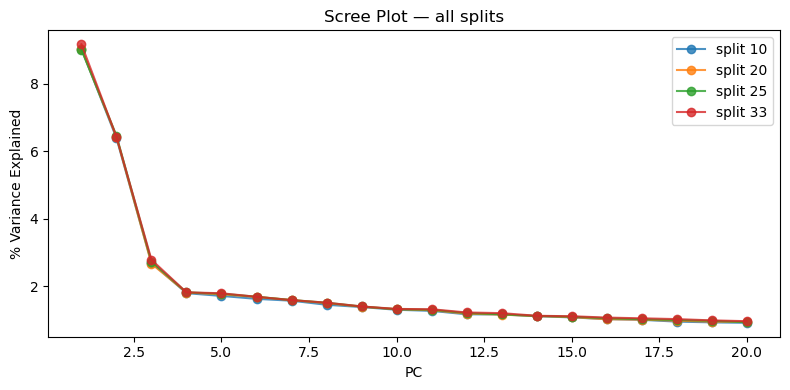

In [5]:
# scree plot — variance of training PC scores
# overlaying all splits to check whether eigenstructure is stable across split ratios

fig, ax = plt.subplots(figsize=(8, 4))

for split in splits:
    df = dfs[split]
    pcCols = [c for c in df.columns if c.startswith("PC")]
    trainScores = df[df[split] == 1][pcCols]
    variances = trainScores.var()
    explainedVar = (variances / variances.sum() * 100).values
    ax.plot(range(1, 21), explainedVar[:20], 'o-', label=split.replace("_", " "), alpha=0.8)

ax.set_xlabel("PC")
ax.set_ylabel("% Variance Explained")
ax.set_title("Scree Plot — all splits")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# PC1 mean per region across splits
# Africa should stay negative, others positive across all splits

print(f"{'Region':<25}" + "".join(f"{s:>12}" for s in splits))
print("-" * 73)

for region in sorted(dfs["split_20"]["label"].unique()):
    row = f"{region:<25}"
    for split in splits:
        df = dfs[split]
        row += f"{df.loc[df['label'] == region, 'PC1'].mean():>12.2f}"
    print(row)

Region                       split_10    split_20    split_25    split_33
-------------------------------------------------------------------------
AFRICA                         -34.67      -34.63      -34.63      -34.59
AMERICA                         13.01       12.73       12.71       12.57
CENTRAL_SOUTH_ASIA              10.55       10.57       10.53       10.55
EAST_ASIA                       10.93       10.76       10.84       10.72
EUROPE                          14.96       15.16       15.10       15.14
MIDDLE_EAST                      4.87        4.97        4.95        5.04
OCEANIA                          1.70        1.73        1.80        1.79


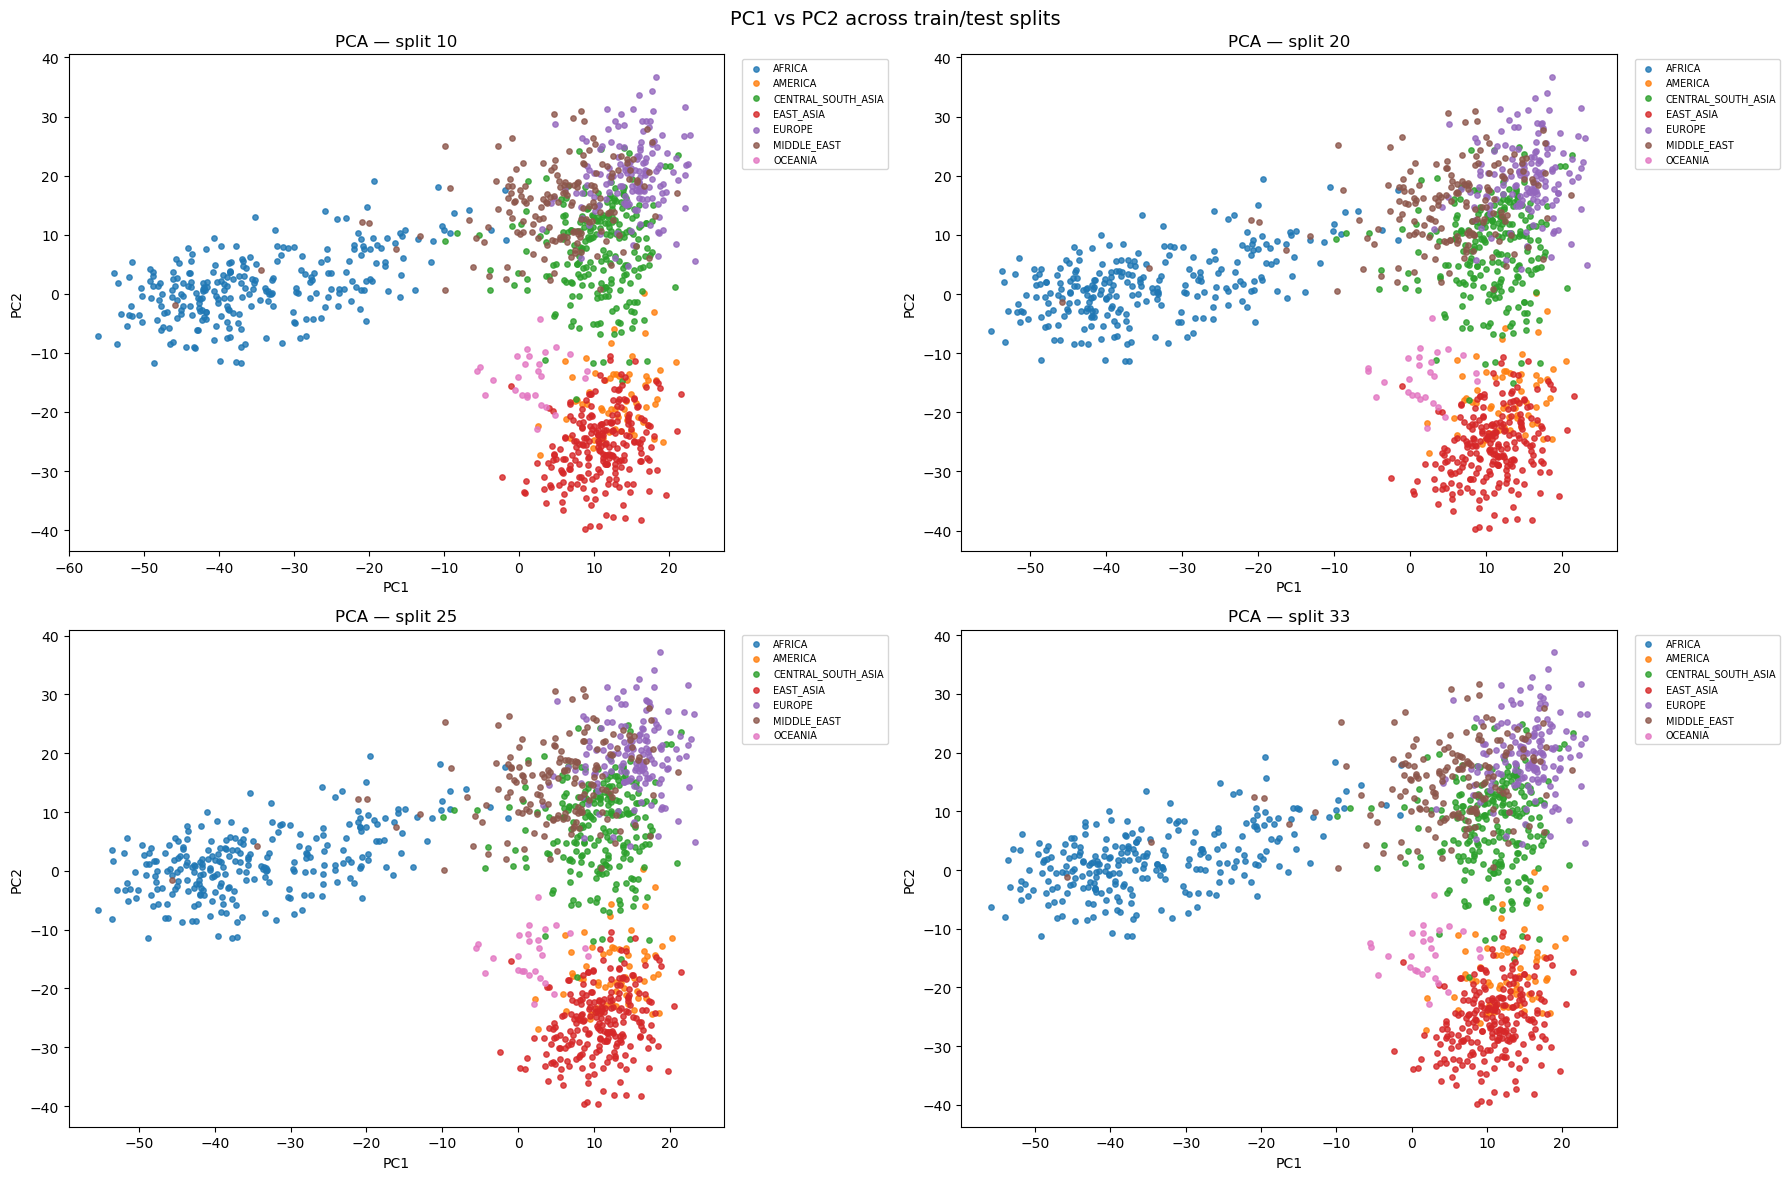

In [7]:
# PC1 vs PC2 — one per split
# cluster structure should remain stable across splits

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, split in zip(axes.flat, splits):
    df = dfs[split]
    for region in sorted(df["label"].unique()):
        mask = df["label"] == region
        ax.scatter(df.loc[mask, "PC1"], df.loc[mask, "PC2"], label=region, s=15, alpha=0.8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"PCA — {split.replace('_', ' ')}")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("PC1 vs PC2 across train/test splits", fontsize=14)
plt.tight_layout()
plt.show()

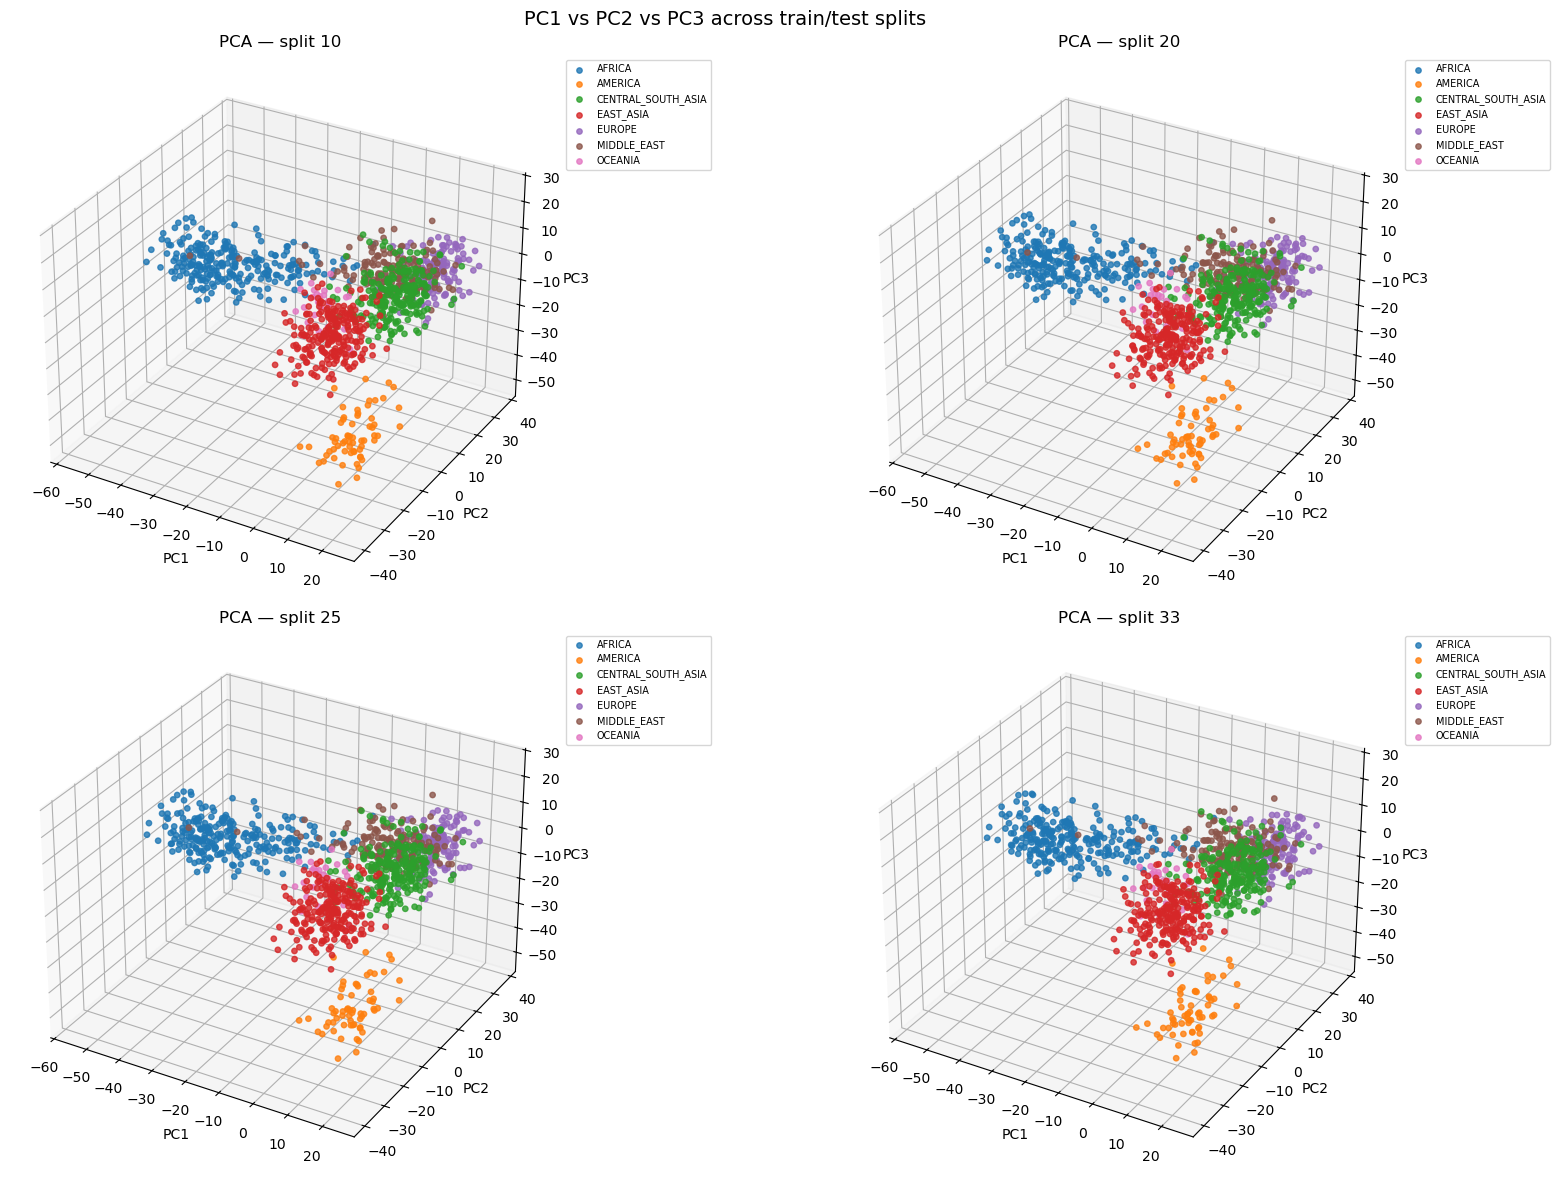

In [8]:
# 3D PCA — 2x2 subplots, one per split

fig = plt.figure(figsize=(18, 12))

for i, split in enumerate(splits):
    df = dfs[split]
    ax3d = fig.add_subplot(2, 2, i + 1, projection="3d")
    for region in sorted(df["label"].unique()):
        mask = df["label"] == region
        ax3d.scatter(df.loc[mask, "PC1"], df.loc[mask, "PC2"], df.loc[mask, "PC3"],label=region, s=15, alpha=0.8)
    ax3d.set_xlabel("PC1")
    ax3d.set_ylabel("PC2")
    ax3d.set_zlabel("PC3")
    ax3d.set_title(f"PCA — {split.replace('_', ' ')}")
    ax3d.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("PC1 vs PC2 vs PC3 across train/test splits", fontsize=14)
plt.tight_layout()
plt.show()

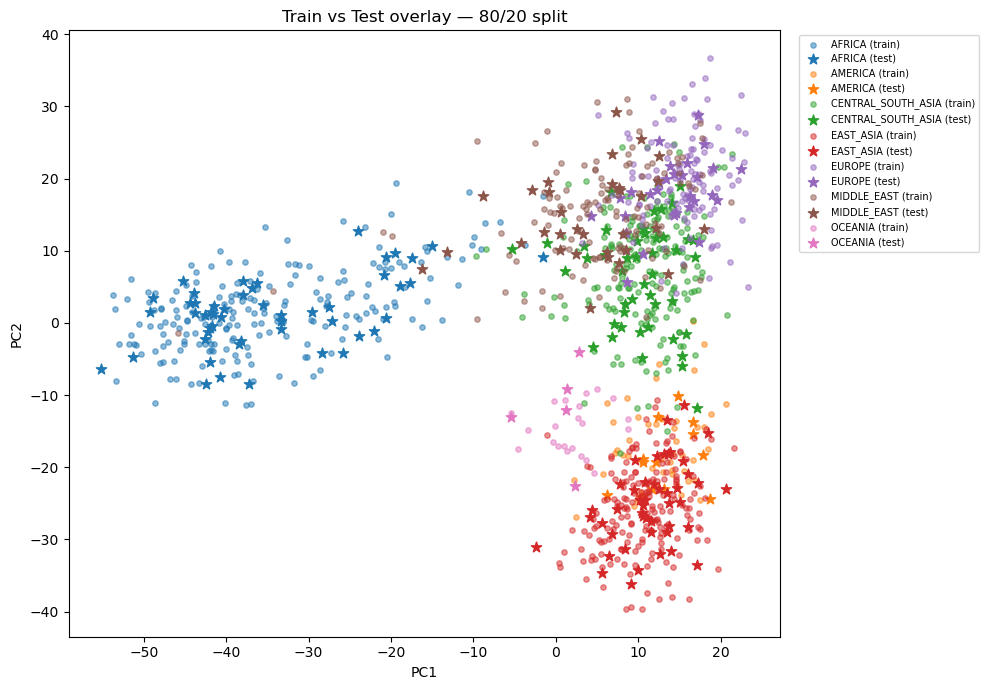

In [9]:
# train vs test data overlay for 80/20 split
# test points as stars on top of train points
# checks test samples fall within training clusters

split = "split_20"
df = dfs[split]
regions = sorted(df["label"].unique())
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 7))

for i, region in enumerate(regions):
    mask_train = (df["label"] == region) & (df[split] == 1)
    mask_test  = (df["label"] == region) & (df[split] == 0)
    ax.scatter(df.loc[mask_train, "PC1"], df.loc[mask_train, "PC2"], color=colors[i], s=15, alpha=0.5, label=f"{region} (train)")
    ax.scatter(df.loc[mask_test,  "PC1"], df.loc[mask_test,  "PC2"], color=colors[i], s=60, alpha=1.0, marker="*", label=f"{region} (test)")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Train vs Test overlay — 80/20 split")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

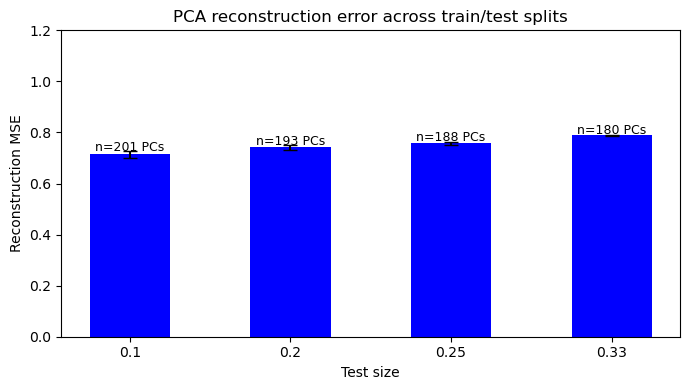

In [12]:
# reconstruction error bar chart showing how well training PCs reconstruct held-out test samples
# error bars show std across folds — wide bars signal instability across CV folds
# gradual increase with test size expected; large jump signals instability

cvResults = pd.read_csv("../data/pcaCV_results.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cvResults["test_size"].astype(str), cvResults["avg_reconError"],yerr=cvResults["std_reconError"], capsize=5, color="blue", width=0.5)
ax.set_xlabel("Test size")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("PCA reconstruction error across train/test splits")
ax.set_ylim(0, 1.2)
for i, row in cvResults.iterrows():
    ax.text(i, row["avg_reconError"] + row["std_reconError"] + 0.002, f'n={int(row["avg_nComponents"])} PCs', ha="center", fontsize=9)
plt.tight_layout()
plt.show()